
### Late Delivery Prediction — Classification Model

### **Objective:** Predict which orders will arrive late, enabling proactive 
### logistics flagging before delivery. This model uses order-level features 
### available at the time of purchase (price, freight, category, location, 
### order timing) to classify orders as at-risk of late delivery.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay,
    precision_recall_curve
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import shap
import joblib

print("Libraries loaded ✅")
master_df = pd.read_csv("master_olist_dataset.csv")
master_df.head()



Libraries loaded ✅


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_category_name_english,delivery_delay_days,is_late_delivery,total_order_value,order_month,order_year,order_day,order_hour,is_weekend,review_sentiment
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,housewares,-8.0,0,38.71,October,2017,Monday,10,0,Positive
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,housewares,-8.0,0,38.71,October,2017,Monday,10,0,Positive
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,housewares,-8.0,0,38.71,October,2017,Monday,10,0,Positive
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,perfumery,-6.0,0,141.46,July,2018,Tuesday,20,0,Positive
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,auto,-18.0,0,179.12,August,2018,Wednesday,8,0,Positive


## 2. Feature Selection
#### Using only features available at order time (no data leakage from 
#### post-delivery information).


In [2]:
features = [
    "price", "freight_value", "payment_type",
    "seller_state", "customer_state",
    "product_category_name_english",
    "product_weight_g", "order_hour", "is_weekend"
]
target = "is_late_delivery"

df = master_df[features + [target]].copy()
df.head()

X = df.drop(columns=target)
y = df[target]

categorical_features = [
    "payment_type", "seller_state", "customer_state",
    "product_category_name_english"
]
numeric_features = [
    "price", "freight_value", "product_weight_g",
    "order_hour", "is_weekend"
]

print("Class distribution:")
print(y.value_counts(normalize=True).round(3))

Class distribution:
is_late_delivery
0    0.937
1    0.063
Name: proportion, dtype: float64


In [3]:
# ## 3. Preprocessing Pipeline

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessor ready ✅")

Preprocessor ready ✅


In [4]:
# 4. Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train shape: (95314, 9)
Test shape : (23829, 9)


c:\Users\yradh\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\yradh\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logistic Regression Results
Accuracy : 0.937
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.655


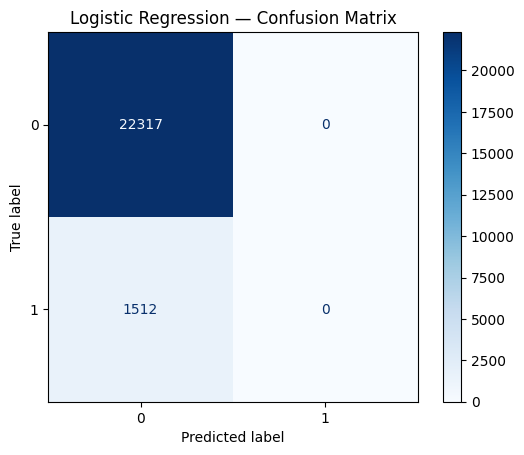

In [5]:

# ## 5. Baseline Model — Logistic Regression

lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)

y_pred = lr_pipeline.predict(X_test)
y_prob = lr_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall   :", round(recall_score(y_test, y_pred), 3))
print("F1 Score :", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 3))

# %%
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Logistic Regression — Confusion Matrix")
plt.show()



In [6]:
## 6. Baseline Model — Random Forest

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest (baseline) Results")
print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 3))
print("Precision:", round(precision_score(y_test, y_pred_rf), 3))
print("Recall   :", round(recall_score(y_test, y_pred_rf), 3))
print("F1 Score :", round(f1_score(y_test, y_pred_rf), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_rf), 3))


Random Forest (baseline) Results
Accuracy : 0.937
Precision: 1.0
Recall   : 0.003
F1 Score : 0.005
ROC-AUC  : 0.671


## **Key observation:** Despite ~94% accuracy, recall is very low. With 
#### only ~7% of orders being late, a model that predicts "on-time" for 
#### almost everything still scores high on accuracy while catching almost 
#### no actual late deliveries. This is a class imbalance problem — 
#### addressed with hyperparameter tuning and SMOTE below.


In [7]:


# ## 7. Hyperparameter Tuning (RandomizedSearchCV on a sample for speed)
sample_size = min(20000, len(X_train))
X_train_sample = X_train.sample(n=sample_size, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

rf_param_dist = {
    "classifier__n_estimators": [100, 150, 200],
    "classifier__max_depth": [10, 15, 20, None],
    "classifier__min_samples_split": [2, 5, 10]
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=6,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X_train_sample, y_train_sample)

print("Best RF Parameters:", rf_search.best_params_)
print("Best RF CV F1 Score:", round(rf_search.best_score_, 3))


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best RF Parameters: {'classifier__n_estimators': 100, 'classifier__min_samples_split': 5, 'classifier__max_depth': None}
Best RF CV F1 Score: 0.025


Final Random Forest Results
Accuracy : 0.941
Precision: 0.83
Recall   : 0.087
F1 Score : 0.158
ROC-AUC  : 0.73


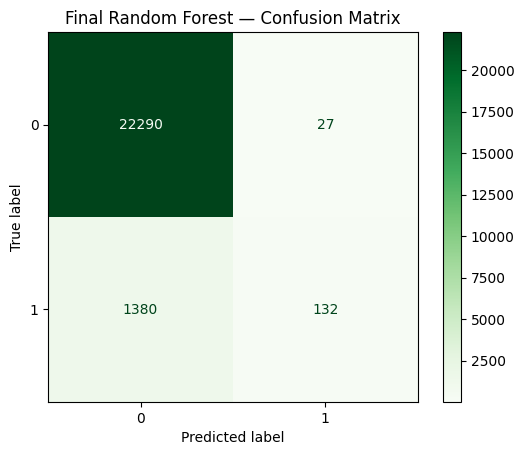

In [8]:

# ## 8. Final Model — Random Forest (tuned, trained on full data)

best_params = rf_search.best_params_

best_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=best_params["classifier__n_estimators"],
        max_depth=best_params["classifier__max_depth"],
        min_samples_split=best_params["classifier__min_samples_split"],
        random_state=42,
        n_jobs=-1
    ))
])

best_rf.fit(X_train, y_train)

y_pred_final = best_rf.predict(X_test)
y_prob_final = best_rf.predict_proba(X_test)[:, 1]

print("Final Random Forest Results")
print("Accuracy :", round(accuracy_score(y_test, y_pred_final), 3))
print("Precision:", round(precision_score(y_test, y_pred_final), 3))
print("Recall   :", round(recall_score(y_test, y_pred_final), 3))
print("F1 Score :", round(f1_score(y_test, y_pred_final), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_final), 3))

# %%
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, cmap="Greens")
plt.title("Final Random Forest — Confusion Matrix")
plt.show()

c:\Users\yradh\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                   Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0    Logistic Regression     0.937       0.00   0.000     0.000    0.655
1  Random Forest (tuned)     0.941       0.83   0.087     0.158    0.730


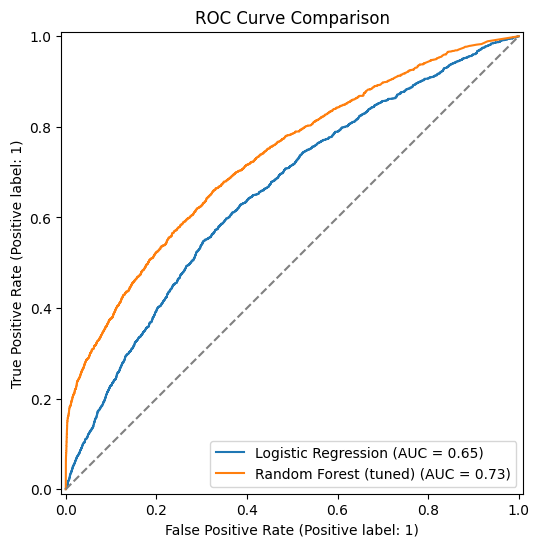

In [9]:

# ## 9. Model Comparison

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest (tuned)"],
    "Accuracy": [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_final)],
    "Precision": [precision_score(y_test, y_pred), precision_score(y_test, y_pred_final)],
    "Recall": [recall_score(y_test, y_pred), recall_score(y_test, y_pred_final)],
    "F1 Score": [f1_score(y_test, y_pred), f1_score(y_test, y_pred_final)],
    "ROC-AUC": [roc_auc_score(y_test, y_prob), roc_auc_score(y_test, y_prob_final)]
}).round(3)

print(comparison)

# %%
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_estimator(lr_pipeline, X_test, y_test, ax=ax, name="Logistic Regression")
RocCurveDisplay.from_estimator(best_rf, X_test, y_test, ax=ax, name="Random Forest (tuned)")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve Comparison")
plt.show()




### 10. Addressing Class Imbalance — SMOTE
# 
#### Since tuning alone did not meaningfully improve recall, SMOTE 
#### (Synthetic Minority Oversampling) is applied to the training data to 
#### rebalance the classes before fitting the classifier.


SMOTE Random Forest Results
Accuracy : 0.854
Precision: 0.138
Recall   : 0.247
F1 Score : 0.177
ROC-AUC  : 0.654


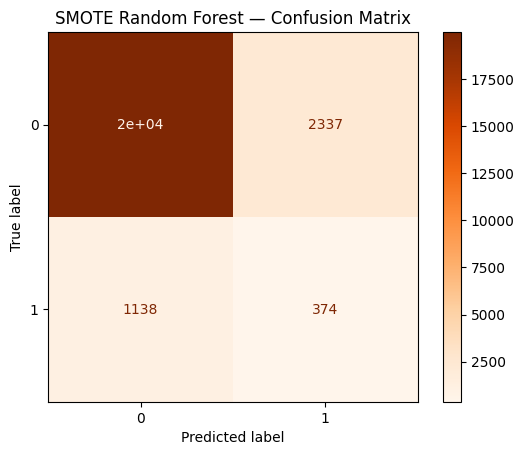

In [10]:
rf_pipeline_smote = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(
        n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
    ))
])

rf_pipeline_smote.fit(X_train, y_train)

y_pred_smote = rf_pipeline_smote.predict(X_test)
y_prob_smote = rf_pipeline_smote.predict_proba(X_test)[:, 1]

print("SMOTE Random Forest Results")
print("Accuracy :", round(accuracy_score(y_test, y_pred_smote), 3))
print("Precision:", round(precision_score(y_test, y_pred_smote), 3))
print("Recall   :", round(recall_score(y_test, y_pred_smote), 3))
print("F1 Score :", round(f1_score(y_test, y_pred_smote), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_smote), 3))

# %%
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote, cmap="Oranges")
plt.title("SMOTE Random Forest — Confusion Matrix")
plt.show()


### **Result:** SMOTE improved recall from 0.087 (baseline tuned model) to 
##### 0.247 — nearly 3x better at catching actual late deliveries — at the 
##### cost of precision dropping from 0.83 to 0.138. This is treated as the 
##### **final model**, since for this business problem, catching more at-risk 
##### orders is more valuable than avoiding false alarms.

### 11. Threshold Tuning (Precision-Recall Trade-off)


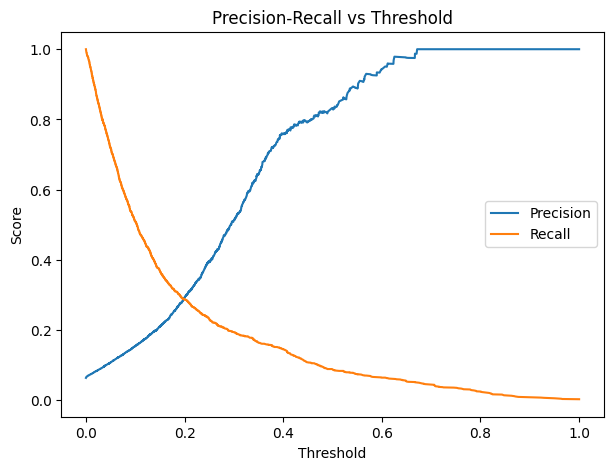

At threshold=0.35:
Precision: 0.644
Recall   : 0.164
F1 Score : 0.261


In [11]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_final)

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.show()


custom_threshold = 0.35
y_pred_custom = (y_prob_final >= custom_threshold).astype(int)

print(f"At threshold={custom_threshold}:")
print("Precision:", round(precision_score(y_test, y_pred_custom), 3))
print("Recall   :", round(recall_score(y_test, y_pred_custom), 3))
print("F1 Score :", round(f1_score(y_test, y_pred_custom), 3))


C:\Users\yradh\AppData\Local\Temp\ipykernel_6188\4039880172.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x="importance", y="feature", palette="viridis")


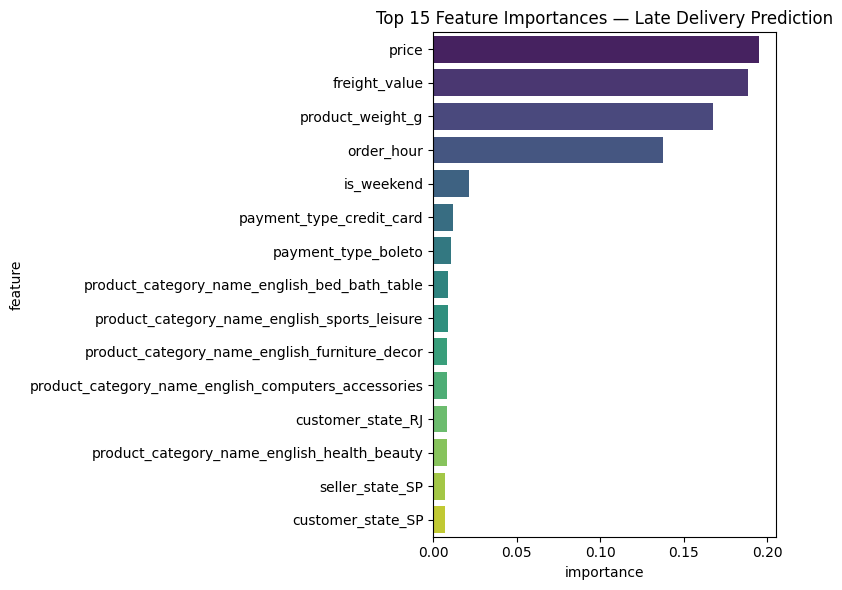

In [12]:

# ## 12. Feature Importance

ohe_columns = best_rf.named_steps["preprocessor"]\
    .named_transformers_["cat"].named_steps["encoder"]\
    .get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(ohe_columns)
importances = best_rf.named_steps["classifier"].feature_importances_

feat_imp_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=feat_imp_df, x="importance", y="feature", palette="viridis")
plt.title("Top 15 Feature Importances — Late Delivery Prediction")
plt.tight_layout()
plt.show()


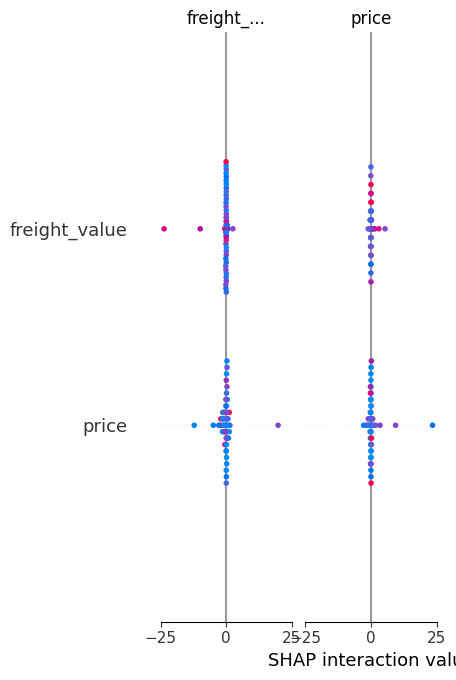

In [13]:

X_sample = X_test.sample(50, random_state=42)
X_sample_processed = best_rf.named_steps["preprocessor"].transform(X_sample)

if hasattr(X_sample_processed, "toarray"):
    X_sample_processed = X_sample_processed.toarray()

explainer = shap.TreeExplainer(best_rf.named_steps["classifier"])
shap_values = explainer.shap_values(X_sample_processed, check_additivity=False)

shap.summary_plot(
    shap_values[1] if isinstance(shap_values, list) else shap_values,
    X_sample_processed,
    feature_names=all_feature_names,
    show=True
)


In [14]:

# ## 14. Save Final Model

joblib.dump(rf_pipeline_smote, "late_delivery_model_smote.pkl")
print("Final model saved as late_delivery_model_smote.pkl ✅")


Final model saved as late_delivery_model_smote.pkl ✅



### 15. Business Interpretation
# 
###**1. Class imbalance discovery:** The baseline Random Forest had high 
#### precision (0.83) but very low recall (0.087) despite 94.1% accuracy — 
#### a classic "accuracy paradox" caused by severe class imbalance 
#### (~7% of orders are late). High accuracy alone was misleading; the model 
#### was essentially always predicting "on-time."
# 
### **2. Fix applied:** SMOTE oversampling improved recall to 0.247 
#### (nearly 3x better) at the cost of precision dropping to 0.138. This is 
#### an accepted trade-off — for this business problem, catching more 
#### at-risk orders matters more than avoiding some false alarms.
# 
### **3. Limitation:** Available features (price, freight, category, state) 
#### have only moderate predictive power for delivery delays (ROC-AUC ≈ 0.65). 
#### Stronger predictors — real-time courier capacity, traffic, or warehouse 
#### processing time — are not available in this dataset. This model should 
#### **not** be treated as production-ready in isolation.
# 
### **4. Recommendation:** Use this model as an early-warning filter — 
#### flagging the highest-risk orders (e.g., top 25% by predicted 
#### probability) for manual logistics review, rather than as a standalone 
#### automated decision-maker.